In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [50]:
data_chrun = pd.read_csv(r"C:\Users\Monika Dogra\Desktop\data\customer_churn_feature_engineering.csv")
display(data_chrun.head())

,Age,MonthlyIncome,TenureMonths,NumProducts,City,Gender,ContractType,RegistrationDate,Churn
0,56.0,72593.21,5.0,3,Mumbai,Female,Yearly,2022-04-29,0
1,69.0,56518.12,3.0,1,Pune,Male,Monthly,2019-11-20,1
2,46.0,71912.00,65.0,2,Pune,Female,Monthly,2023-11-26,0
3,32.0,37832.45,4.0,3,Mumbai,Male,Monthly,2019-10-11,1
4,60.0,94176.05,64.0,2,Mumbai,Female,Monthly,2019-08-01,0


In [51]:
display(data_chrun.info())
display(data_chrun.describe())
display(data_chrun.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               995 non-null    float64
 1   MonthlyIncome     984 non-null    float64
 2   TenureMonths      1010 non-null   float64
 3   NumProducts       1010 non-null   int64  
 4   City              998 non-null    object 
 5   Gender            1010 non-null   object 
 6   ContractType      1000 non-null   object 
 7   RegistrationDate  1010 non-null   object 
 8   Churn             1010 non-null   int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 71.1+ KB


None

,Age,MonthlyIncome,TenureMonths,NumProducts,Churn
count,995.000000,984.000000,1010.000000,1010.000000,1010.000000
mean,45.023116,57460.665701,36.310891,1.989109,0.305941
std,16.959369,40893.470222,20.511216,0.846423,0.461033
min,18.000000,-23500.520000,0.000000,1.000000,0.000000
25%,32.000000,40572.942500,19.000000,1.000000,0.000000
50%,45.000000,56150.880000,36.000000,2.000000,0.000000
75%,57.000000,71336.605000,54.000000,3.000000,1.000000
max,150.000000,600000.000000,72.000000,4.000000,1.000000


(1010, 9)

In [52]:
display(data_chrun.isnull().sum())
display((data_chrun==0).sum())

Age                 15
MonthlyIncome       26
TenureMonths         0
NumProducts          0
City                12
Gender               0
ContractType        10
RegistrationDate     0
Churn                0
dtype: int64

Age                   0
MonthlyIncome         0
TenureMonths          5
NumProducts           0
City                  0
Gender                0
ContractType          0
RegistrationDate      0
Churn               701
dtype: int64

In [53]:
missing_percentage = (
    data_chrun.isnull().mean() * 100
)

print(missing_percentage)

Age                 1.485149
MonthlyIncome       2.574257
TenureMonths        0.000000
NumProducts         0.000000
City                1.188119
Gender              0.000000
ContractType        0.990099
RegistrationDate    0.000000
Churn               0.000000
dtype: float64


In [54]:
display(data_chrun.duplicated().sum())

# display(data_chrun.duplicated())
# display(data_chrun.duplicated(keep=False))

10

In [55]:
display(data_chrun["Churn"].value_counts())

display(data_chrun["Churn"].value_counts(normalize=True) * 100)
#the classes are somewhat imbalanced.

0    701
1    309
Name: Churn, dtype: int64

0    69.405941
1    30.594059
Name: Churn, dtype: float64

In [56]:
# check categorical columns:
display(data_chrun["City"].value_counts())
display(data_chrun["ContractType"].value_counts())
display(data_chrun["Gender"].value_counts())

Pune         251
Mumbai       232
Delhi        205
Bangalore    181
Hyderabad    129
Name: City, dtype: int64

Monthly      565
Yearly       249
Quarterly    186
Name: ContractType, dtype: int64

Male      539
Female    471
Name: Gender, dtype: int64

In [57]:
display((data_chrun["City"]=='NaN').sum())
display(data_chrun["City"].nunique())
display(data_chrun["ContractType"].nunique())
#High-cardinality(no. of unique values) columns can become problematic with one-hot encoding.

0

5

3

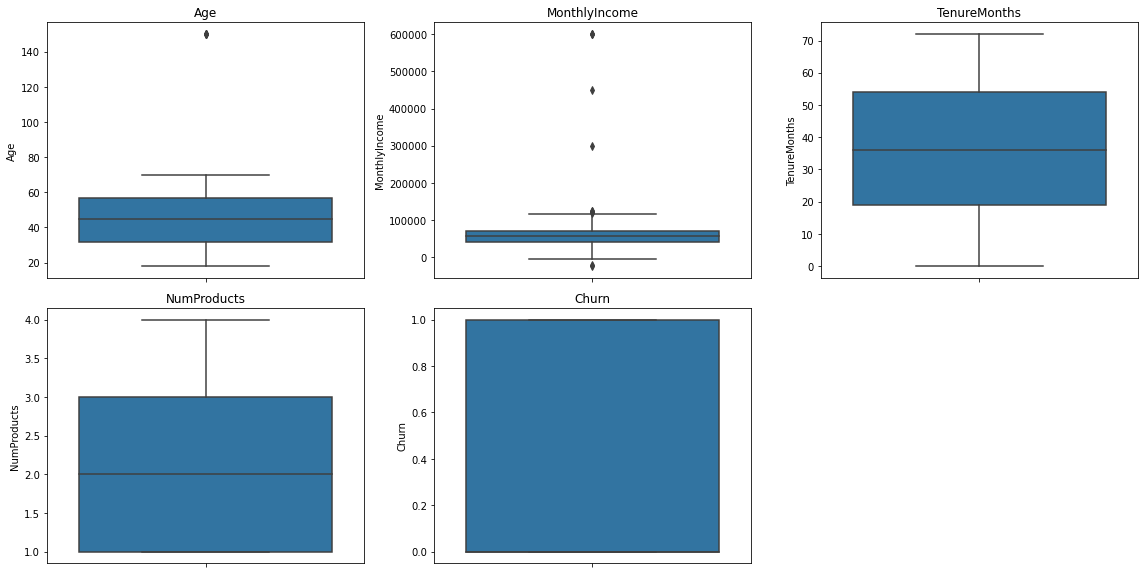

In [58]:
# draw Outliers:
numeric_columns = data_chrun.select_dtypes(include="number").columns
plt.figure(figsize=(16,12))
for i, column in enumerate(numeric_columns, 1):

    plt.subplot(3,3,i)

    sns.boxplot(
        y=data_chrun[column]
    )

    plt.title(column)

plt.tight_layout()

plt.show()

# Here Age can't be 150 and income can't be -ve
# and tenure as zero -->will find zero/invalid tenure according to our business assumption.

## Data Cleaning

In [59]:
# Drop duplicates:
display(data_chrun.duplicated().sum())
# checking whether the duplicate rows you're dropping are truly identical ot not?
duplicates = data_chrun[data_chrun.duplicated(keep=False)]
display(duplicates)
data_chrun = data_chrun.drop_duplicates()
display(data_chrun.duplicated().sum())

10

,Age,MonthlyIncome,TenureMonths,NumProducts,City,Gender,ContractType,RegistrationDate,Churn
0,56.0,72593.21,5.0,3,Mumbai,Female,Yearly,2022-04-29,0
1,69.0,56518.12,3.0,1,Pune,Male,Monthly,2019-11-20,1
2,46.0,71912.00,65.0,2,Pune,Female,Monthly,2023-11-26,0
3,32.0,37832.45,4.0,3,Mumbai,Male,Monthly,2019-10-11,1
4,60.0,94176.05,64.0,2,Mumbai,Female,Monthly,2019-08-01,0
5,25.0,NaN,10.0,1,Bangalore,Male,Yearly,2023-07-17,0
6,38.0,63804.82,21.0,1,Pune,Male,Monthly,2023-10-08,1
7,56.0,37740.74,46.0,1,Bangalore,Male,Yearly,2021-07-17,0
8,36.0,65380.19,27.0,2,Delhi,Male,Quarterly,2021-01-21,0
9,40.0,69323.43,66.0,2,Mumbai,Male,Monthly,2022-11-18,0


0

## Handle Impossible Age Values

In [60]:
invalid_ages = data_chrun[(data_chrun["Age"]< 18) | (data_chrun["Age"]>100)]
display(invalid_ages)
#Age < 18 → invalid
# Age > 100 → suspicious/invalid for this exercise

,Age,MonthlyIncome,TenureMonths,NumProducts,City,Gender,ContractType,RegistrationDate,Churn
255,150.0,54926.28,48.0,1,Pune,Female,Monthly,2025-06-23,1
602,150.0,51403.72,56.0,2,Pune,Male,Monthly,2023-07-26,0
713,150.0,56389.64,13.0,2,Pune,Male,Monthly,2022-09-10,0
816,150.0,NaN,53.0,2,Delhi,Female,Yearly,2020-07-13,0
853,150.0,68917.67,70.0,1,Pune,Male,Monthly,2022-07-15,1


In [61]:
#What Should We Do With Invalid Age?
#option 1: remove the row:
# This is reasonable when:
# only a tiny percentage is affected
# values are clearly erroneous
# there is no reliable way to recover them

# option2.:Convert invalid values to missing: often safer
# Then we can handle them through our normal missing-value strategy.
# I prefer this approach when the row itself may contain useful information.

data_chrun.loc[(data_chrun["Age"]< 18) | (data_chrun["Age"]>100)] = pd.NA
# display(data_chrun["Age"]== NA)

In [62]:
data_chrun["Age"].isnull().sum()
# earlier it was 15 now new 5 invalid values became missing.
#Why Not Replace Age 150 With 40 or any other number:If there is no reliable reason, we're inventing data.
# Better--->find invalids-->NaN-->Imputation using training data

20

## Negative Monthly Income

In [63]:
# Negative monthly income doesn't make sense for this dataset.
display(data_chrun[data_chrun["MonthlyIncome"]<0].shape)

data_chrun.loc[data_chrun["MonthlyIncome"]<0] = pd.NA

(12, 9)

In [64]:
display(data_chrun[data_chrun["MonthlyIncome"]<0])

,Age,MonthlyIncome,TenureMonths,NumProducts,City,Gender,ContractType,RegistrationDate,Churn


In [65]:
#Check Missing Values Again
display(data_chrun.isna().sum())

# now missing values includes:Original NaN + Invalid values converted to NaN
# will do all the imputation after splitting the data after creating the pipeline inorder to avoid the data lekage issue.

Age                 32
MonthlyIncome       41
TenureMonths        17
NumProducts         17
City                28
Gender              17
ContractType        27
RegistrationDate    17
Churn               17
dtype: int64

## Outliers:

In [66]:
# Detecting Outliers with IQR

Q1 = data_chrun["MonthlyIncome"].quantile(0.25)
Q3 = data_chrun["MonthlyIncome"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data_chrun[
    (data_chrun["MonthlyIncome"] < lower_bound) |
    (data_chrun["MonthlyIncome"] > upper_bound)
]

display(outliers)
display(outliers.shape)

,Age,MonthlyIncome,TenureMonths,NumProducts,City,Gender,ContractType,RegistrationDate,Churn
118,52.0,124837.73,57.0,3,Pune,Male,Monthly,2022-01-08,0
234,19.0,300000.0,36.0,2,Mumbai,Female,Quarterly,2024-08-04,0
547,22.0,123069.08,62.0,4,Hyderabad,Male,Monthly,2025-10-14,0
561,33.0,119816.68,60.0,2,Pune,Male,Monthly,2019-04-20,0
684,40.0,124123.27,19.0,3,Hyderabad,Female,Monthly,2023-06-05,1
686,60.0,600000.0,48.0,2,Hyderabad,Male,Monthly,2025-11-09,0
764,36.0,600000.0,3.0,1,Pune,Male,Monthly,2019-10-24,0
948,33.0,450000.0,47.0,2,Delhi,Female,Yearly,2025-08-08,0
952,21.0,600000.0,7.0,2,Bangalore,Male,Monthly,2024-07-24,0


(9, 9)

## Feature Engineering:
understand the data problems, we'll create meaningful features from our raw columns.

In [67]:
# convert the data columns:
data_chrun["RegistrationDate"] = pd.to_datetime(
                        data_chrun["RegistrationDate"],
                        errors="coerce")
# why errors="coerce" if dataset contains any invalid date: "2025-99-99" make that NaT(not a time)

In [68]:
#Extract Year
data_chrun["RegistrationYear"] = (
    data_chrun["RegistrationDate"].dt.year
)

# Extract Month
data_chrun["RegistrationMonth"] = (
    data_chrun["RegistrationDate"].dt.month
)
#Extract Day of Week
data_chrun["RegistrationDayOfWeek"] = (
    data_chrun["RegistrationDate"].dt.dayofweek
)

data_chrun = data_chrun.drop(
    "RegistrationDate",
    axis=1
)
display(data_chrun.head())

,Age,MonthlyIncome,TenureMonths,NumProducts,City,Gender,ContractType,Churn,RegistrationYear,RegistrationMonth,RegistrationDayOfWeek
0,56.0,72593.21,5.0,3,Mumbai,Female,Yearly,0,2022.0,4.0,4.0
1,69.0,56518.12,3.0,1,Pune,Male,Monthly,1,2019.0,11.0,2.0
2,46.0,71912.0,65.0,2,Pune,Female,Monthly,0,2023.0,11.0,6.0
3,32.0,37832.45,4.0,3,Mumbai,Male,Monthly,1,2019.0,10.0,4.0
4,60.0,94176.05,64.0,2,Mumbai,Female,Monthly,0,2019.0,8.0,3.0


In [69]:
# income column:
data_chrun["MonthlyIncome"].describe()

# display(data_chrun["MonthlyIncome"].skew())

#If the value is strongly positive, the distribution is right-skewed.

count        959.0
unique       957.0
top       600000.0
freq           3.0
Name: MonthlyIncome, dtype: float64

### Features and pipelines:

In [70]:
# Should Registration Year Be Scaled?
# Yes, if we're treating it as a numerical feature in Logistic Regression.

numeric_features = [
    "Age",
    "MonthlyIncome",
    "TenureMonths",
    "NumProducts",
    "RegistrationYear",
    "RegistrationMonth"
]

categorical_features = [
    "City",
    "Gender",
    "ContractType"
]

In [71]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [72]:
#ColumnTransformer:Apply numeric_pipeline to numerical columns and categorical_pipeline to categorical columns.
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])


In [73]:
#Add Logistic Regression
model_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])

#Why This Is Better Than Manual Preprocessing:Most Important Benefit: Preventing Leakage

In [77]:
# split the data:
# Remove rows where target is missing
# as our target column has few missing values:
#We normally remove those rows rather than impute the target.

data_chrun = data_chrun.dropna(subset=["Churn"])
data_chrun["Churn"] = data_chrun["Churn"].astype(int)
# Recreate X and y AFTER removing missing target rows
data_chrun["Churn"].isnull().sum()

0

In [78]:
X = data_chrun.drop(columns=["Churn"])
y = data_chrun["Churn"]

# Check everything
display("DataFrame shape:", data_chrun.shape)
display("X shape:", X.shape)
display("y shape:", y.shape)

display("\nChurn distribution:")
display(data_chrun["Churn"].value_counts(dropna=False))

display("\ny missing values:")
display(y.isna().sum())

'DataFrame shape:'

(983, 11)

'X shape:'

(983, 10)

'y shape:'

(983,)

'\nChurn distribution:'

0    682
1    301
Name: Churn, dtype: int64

'\ny missing values:'

0

In [79]:
display(type(y))
display(y.dtype)
display(y.head())
display(y.value_counts())
display(y.isna().sum())

pandas.core.series.Series

dtype('int32')

0    0
1    1
2    0
3    1
4    0
Name: Churn, dtype: int32

0    682
1    301
Name: Churn, dtype: int64

0

In [80]:
print("Missing values in X:")
print(X.isna().sum())

print("\nTotal missing values in X:")
print(X.isna().sum().sum())
print(X.dtypes)

Missing values in X:
Age                      15
MonthlyIncome            24
TenureMonths              0
NumProducts               0
City                     11
Gender                    0
ContractType             10
RegistrationYear          0
RegistrationMonth         0
RegistrationDayOfWeek     0
dtype: int64

Total missing values in X:
60
Age                       object
MonthlyIncome             object
TenureMonths              object
NumProducts               object
City                      object
Gender                    object
ContractType              object
RegistrationYear         float64
RegistrationMonth        float64
RegistrationDayOfWeek    float64
dtype: object


In [81]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX missing values:")
print(X.isna().sum())

print("\nTotal X missing:", X.isna().sum().sum())

print("\ny missing:", y.isna().sum())

print("\ny dtype:", y.dtype)

print("\ny values:")
print(y.value_counts(dropna=False))

X shape: (983, 10)
y shape: (983,)

X missing values:
Age                      15
MonthlyIncome            24
TenureMonths              0
NumProducts               0
City                     11
Gender                    0
ContractType             10
RegistrationYear          0
RegistrationMonth         0
RegistrationDayOfWeek     0
dtype: int64

Total X missing: 60

y missing: 0

y dtype: int32

y values:
0    682
1    301
Name: Churn, dtype: int64


In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42, #get the same split every time
    stratify=y     #stratify=y helps preserve the class distribution.
)

In [83]:
# verify the splits:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

X_train: (786, 10)
X_test: (197, 10)

y_train distribution:
0    0.693384
1    0.306616
Name: Churn, dtype: float64

y_test distribution:
0    0.695431
1    0.304569
Name: Churn, dtype: float64


## Train the model

In [84]:
model_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'MonthlyIncome',
                                                   'TenureMonths',
                                                   'NumProducts',
                                                   'RegistrationYear',
                                                   'RegistrationMonth']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImpu

In [85]:
# predict the classes
predictions = model_pipeline.predict(
    X_test
)
probabilities = model_pipeline.predict_proba(X_test)

In [86]:
#predict() vs predict_proba():
# predict():Returns the predicted class:0,1
# predict_proba():Returns probabilities

In [87]:
# get probabilities of "Churn"
probabilities = model_pipeline.predict_proba(X_test)[:, 1]

#These probabilities are useful for:

# ROC-AUC
# threshold tuning
# risk scoring
# prioritizing customers

In [88]:
# Metrics
accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions
)

recall = recall_score(
    y_test,
    predictions
)

f1 = f1_score(
    y_test,
    predictions
)

roc_auc = roc_auc_score(
    y_test,
    probabilities
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy : 0.7106598984771574
Precision: 0.5882352941176471
Recall   : 0.16666666666666666
F1 Score : 0.2597402597402597
ROC-AUC  : 0.6476885644768856

Confusion Matrix:
[[130   7]
 [ 50  10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.95      0.82       137
           1       0.59      0.17      0.26        60

    accuracy                           0.71       197
   macro avg       0.66      0.56      0.54       197
weighted avg       0.68      0.71      0.65       197



## Cross-Validation

In [89]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores = cross_val_score(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("CV scores:", scores)
print("Mean CV accuracy:", scores.mean())

#Cross-validation happens inside the training data.
#The test set should remain untouched until the final evaluation.

CV scores: [0.6835443  0.68152866 0.68152866 0.72611465 0.68789809]
Mean CV accuracy: 0.6921228734983471


In [90]:
# cross_val_score(
#     model_pipeline,
#     X,
#     y,
#     cv=5
# )

### GridSearchCV:
Which hyperparameter combination gives us the best cross-validation performance?

Most Important Parameter: C -->
C controls the inverse of regularization strength.


What Is Regularization?

Regularization discourages the model from learning unnecessarily large coefficients.

In [91]:
# parameter grid:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,    #Use all available CPU cores for parallelizable work.
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'MonthlyIncome',
                                                                          'TenureMonths',
                                                                          'NumProducts',


In [92]:
# find best parameters:
display(
    grid_search.best_params_
)

# best Cv score:
display(
    grid_search.best_score_
)

# get the best model:
best_model = grid_search.best_estimator_

{'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

0.6189305997628408

In [93]:
# final test evaluations:
test_predictions = best_model.predict(
    X_test
)

test_probabilities = best_model.predict_proba(
    X_test
)[:, 1]

In [94]:
print(
    "Accuracy:",
    accuracy_score(y_test, test_predictions)
)

print(
    "Precision:",
    precision_score(y_test, test_predictions)
)

print(
    "Recall:",
    recall_score(y_test, test_predictions)
)

print(
    "F1:",
    f1_score(y_test, test_predictions)
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        test_probabilities
    )
)

Accuracy: 0.7055837563451777
Precision: 0.5625
Recall: 0.15
F1: 0.23684210526315785
ROC-AUC: 0.6445255474452555
